# Implied Volatility Surface

This notebook constructs an implied volatility surface using the Black–Scholes model.

In practice, volatility is not constant. Instead, it varies with:
- Strike price (volatility smile / skew)
- Time to maturity (term structure)

The goal is to recover implied volatility from option prices and visualize its structure.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../src"))

from surface import generate_surface

## Black–Scholes Model

The price of a European call option under the Black–Scholes framework is:

$$
C(S, K, T, r, \sigma) = S \Phi(d_1) - K e^{-rT} \Phi(d_2)
$$

where:

$$
d_1 = \frac{\ln(S/K) + (r + \tfrac{1}{2}\sigma^2)T}{\sigma \sqrt{T}}, \quad
d_2 = d_1 - \sigma \sqrt{T}
$$

- $S$: spot price  
- $ K $: strike price  
- $ T $: time to maturity  
- $ r $: risk-free rate  
- $ \sigma $: volatility  
- $ \Phi(\cdot) $: standard normal CDF  

The model assumes **constant volatility**, which is inconsistent with observed market data.

In [2]:
S = 100
r = 0.03

strikes = np.linspace(60, 140, 60)
maturities = np.linspace(0.05, 2.0, 60)

K_grid, T_grid, true_vol_surface, market_prices, iv_surface = generate_surface(
    S,
    r,
    strikes,
    maturities
)

## Implied Volatility

Implied volatility is defined as the value of $ \sigma $ such that:

$$
C_{market} = C_{BS}(S, K, T, r, \sigma)
$$

Since no closed-form solution exists for $ \sigma $, we solve numerically.

### Bisection Method

We use a bisection algorithm:

1. Start with bounds $ \sigma_{low}, \sigma_{high}$ 
2. Compute midpoint $ \sigma_{mid} $
3. Compare:
  $$ 
   C_{BS}(\sigma_{mid}) \quad \text{vs} \quad C_{market}
  $$ 
4. Narrow the interval
5. Repeat until convergence

This guarantees convergence due to monotonicity of option price in volatility.

In [3]:
print("True vol min:", true_vol_surface.min())
print("True vol max:", true_vol_surface.max())

print("IV min:", iv_surface.min())
print("IV max:", iv_surface.max())

print("Max error:", np.max(np.abs(true_vol_surface - iv_surface)))

True vol min: 0.17674499632255883
True vol max: 0.8157096482780368
IV min: 0.17674499632255897
IV max: 0.8157096482780595
Max error: 7.083222897108499e-14


## Volatility Surface Construction

To simulate realistic market behavior, we define a synthetic volatility surface as a function of:

$$
x = \log\left(\frac{K}{S}\right)
$$

The volatility surface is modeled as:

$$
\sigma(K, T) =
\sigma_0
+ a x^2
+ b x
+ c e^{-dT}
+ e x^2 T
$$

This captures:

- **Smile**: quadratic dependence on moneyness ($x^2 $)
- **Skew**: linear dependence on moneyness ($ x $)
- **Term structure**: decay in volatility over time
- **Interaction effects** between strike and maturity

This synthetic surface is used to generate option prices, which are then inverted to recover implied volatility.

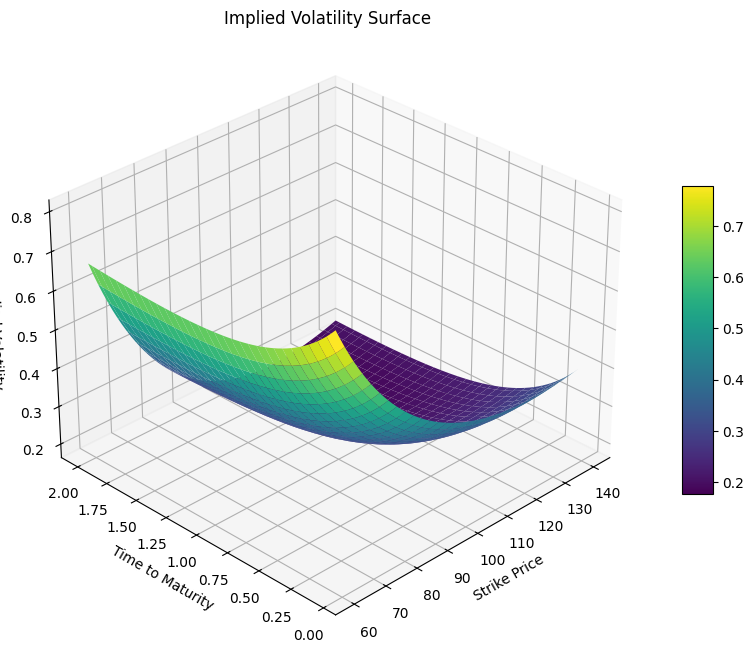

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    K_grid,
    T_grid,
    iv_surface,
    cmap="viridis",
    edgecolor="none"
)

ax.set_xlabel("Strike Price")
ax.set_ylabel("Time to Maturity")
ax.set_zlabel("Implied Volatility")
ax.set_title("Implied Volatility Surface")

ax.view_init(elev=30, azim=-135)

fig.colorbar(surf, shrink=0.5, aspect=10)

plt.savefig("../images/surface.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

The resulting implied volatility surface exhibits:

- **Volatility Smile**: higher implied volatility for deep ITM/OTM options  
- **Volatility Skew**: asymmetry between upside and downside strikes  
- **Term Structure**: variation across maturities  

These features are observed in real financial markets and are essential for:

- Options pricing
- Risk management
- Model calibration